this below cell is used to extract featues from satellite .np dataset

In [23]:
import os
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime

# Update these paths to your local system
satellite_folders = [
    "sorted_june_folder",
    "sorted_july_folder",
    "sorted_august_folder"
]

# Variables you want to extract
variables = ["IMG_VIS", "IMG_MIR", "IMG_SWIR"]

def extract_features_from_nc(file_path):
    features = []
    try:
        ds = xr.open_dataset(file_path)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return []

    for var in variables:
        if var not in ds:
            print(f"Variable {var} not found in {file_path}")
            return []

    for t in ds.time:
        timestamp = pd.to_datetime(t.values)
        row = {"timestamp": timestamp}
        for var in variables:
            data = ds[var].sel(time=t)
            if "latitude" in data.dims and "longitude" in data.dims:
                val = data.mean().item()
            else:
                val = data.item()
            row[var] = val
        features.append(row)

    return features

all_features = []

for folder in satellite_folders:
    if not os.path.isdir(folder):
        print(f"Folder not found: {folder}")
        continue

    files = sorted([f for f in os.listdir(folder) if f.endswith(".nc")])

    # Group files by date (e.g., 13JUL2024)
    grouped_files = {}
    for f in files:
        date_key = f.split("_")[-1].replace(".nc", "")
        grouped_files.setdefault(date_key, []).append(os.path.join(folder, f))

    for date_str, paths in grouped_files.items():
        daily_features = []
        for path in paths:
            daily_features += extract_features_from_nc(path)
        daily_features = sorted(daily_features, key=lambda x: x["timestamp"])
        all_features.extend(daily_features)

# Convert to DataFrame and save
features_df = pd.DataFrame(all_features)
features_df.to_csv("corrected_satellite_features.csv", index=False)
print("Saved to corrected_satellite_features.csv")


Saved to corrected_satellite_features.csv


refinment and trimming of satellite dataset for suitable time frame 

In [47]:
import pandas as pd

# Load the CSV
df = pd.read_csv("corrected_satellite_features.csv", parse_dates=["timestamp"])

# Define the times to remove
excluded_times = ["04:00", "04:15", "18:00", "18:15","18:30", "18:45"]

# Filter the DataFrame
df_filtered = df[~df["timestamp"].dt.strftime("%H:%M").isin(excluded_times)]

# Save to a new CSV
df_filtered.to_csv("trimmed_satellite_features.csv", index=False)

print("Trimmed CSV saved as trimmed_satellite_features.csv")


Trimmed CSV saved as trimmed_satellite_features.csv


cleaning and trimming of GHI csv dataset for proper sync with satellite dataset

In [21]:
import pandas as pd

# Load your GHI CSV
ghi_df = pd.read_csv("Cleaned_GHI_Data.csv", parse_dates=["timestamp"])

# Filter rows between 04:30 and 17:45
ghi_df['time'] = ghi_df['timestamp'].dt.time
ghi_filtered = ghi_df[
    (ghi_df['time'] >= pd.to_datetime("04:30").time()) &
    (ghi_df['time'] <= pd.to_datetime("17:45").time())
].drop(columns=["time"])

# Save the trimmed dataset
ghi_filtered.to_csv("Trimmed_GHI_Data.csv", index=False)


merging of GHI csv and satellite features for the same time in interval of 15 mint from 4:30 to 17:45

In [24]:
import pandas as pd

# Load datasets
ghi_df = pd.read_csv("Trimmed_GHI_Data.csv", parse_dates=["timestamp"])
sat_df = pd.read_csv("satellite_features_all_months.csv", parse_dates=["timestamp"])

# Merge on timestamp (inner join to align properly)
merged_df = pd.merge(ghi_df, sat_df, on="timestamp", how="inner")

# Sort by time to preserve chronological order
merged_df = merged_df.sort_values("timestamp").reset_index(drop=True)

# Ensure all data is before September 1st
merged_df = merged_df[merged_df["timestamp"] < pd.to_datetime("2024-09-01")]

# Determine split index (e.g., 80% for train)
split_idx = int(len(merged_df) * 0.8)

# Split
train_df = merged_df.iloc[:split_idx]
val_df = merged_df.iloc[split_idx:]

# Extract features and targets
X_train = train_df.drop(columns=["GHI", "timestamp"])
y_train = train_df["GHI"]
X_val = val_df.drop(columns=["GHI", "timestamp"])
y_val = val_df["GHI"]

# Save outputs
merged_df.to_csv("Merged_GHI_Satellite.csv", index=False)
X_train.to_csv("X_train.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
X_val.to_csv("X_val.csv", index=False)
y_val.to_csv("y_val.csv", index=False)


training model and evaluation of various performance matrix 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005555 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31303
[LightGBM] [Info] Number of data points in the train set: 1965, number of used features: 125
[LightGBM] [Info] Start training from score 228.518585
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

C:\Users\rajam\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


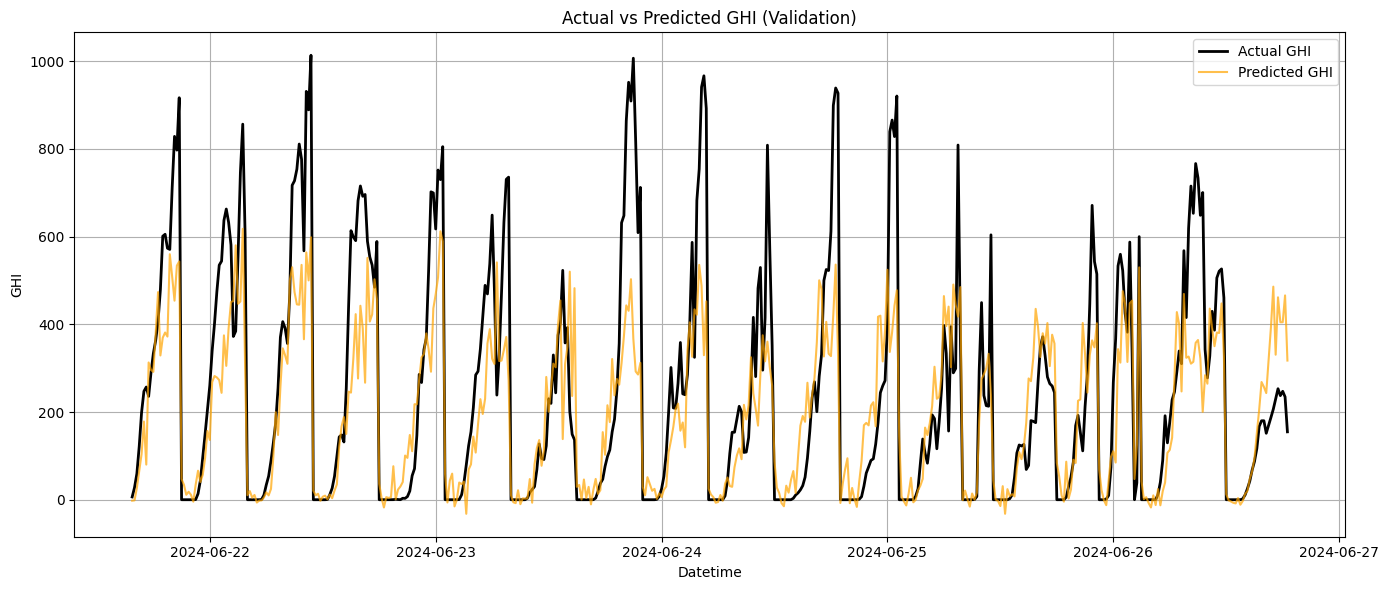

In [56]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, explained_variance_score
import joblib
from datetime import datetime, timedelta

# -------------------- CONFIG --------------------
X_train_path = "X_train.csv"
y_train_path = "y_train.csv"
X_val_path   = "X_val.csv"
y_val_path   = "y_val.csv"
model_save_path = "lgbm_model.pkl"
forecast_save_path = "ghi_forecasts_on_test.csv"

# -------------------- 1. LOAD DATA --------------------
X_train = pd.read_csv(X_train_path)
y_train = pd.read_csv(y_train_path).squeeze()
X_val = pd.read_csv(X_val_path)
y_val = pd.read_csv(y_val_path).squeeze()

# -------------------- 2. CREATE DATETIME INDEX --------------------
start_time = datetime(2024, 6, 1, 4, 30)
end_time = datetime(2024, 8, 31, 17, 45)

full_datetime_index = pd.date_range(start=start_time, end=end_time, freq="15min")

# Filter only the matching size (X_train + X_val)
total_size = len(X_train) + len(X_val)
datetime_index = full_datetime_index[:total_size]
datetime_train = datetime_index[:len(X_train)]
datetime_val = datetime_index[len(X_train):]

# -------------------- 3. TRAIN MODEL --------------------
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
lgb_model.fit(X_train, y_train)

# -------------------- 4. PREDICT & EVALUATE --------------------
y_pred = lgb_model.predict(X_val)

rmse = mean_squared_error(y_val, y_pred, squared=False)
mae = mean_absolute_error(y_val, y_pred)
mape = np.mean(np.abs((y_val - y_pred) / (y_val + 1e-8))) * 100  # avoid div by zero
smape = 100 * np.mean(2 * np.abs(y_pred - y_val) / (np.abs(y_pred) + np.abs(y_val) + 1e-8))
r2 = r2_score(y_val, y_pred)
medae = median_absolute_error(y_val, y_pred)
expl_var = explained_variance_score(y_val, y_pred)

print("------ Forecast Accuracy Metrics ------")
print(f"RMSE                  : {rmse:.3f}")
print(f"MAE                   : {mae:.3f}")
print(f"MAPE (%)              : {mape:.3f}")
print(f"SMAPE (%)             : {smape:.3f}")
print(f"R² Score              : {r2:.3f}")
print(f"Median Absolute Error : {medae:.3f}")
print(f"Explained Variance    : {expl_var:.3f}")

# -------------------- 5. SAVE MODEL & FORECAST --------------------
joblib.dump(lgb_model, model_save_path)

forecast_df = pd.DataFrame({
    "datetime": datetime_val,
    "GHI_actual": y_val,
    "GHI_predicted": y_pred
})
forecast_df.to_csv(forecast_save_path, index=False)

# -------------------- 6. PLOT --------------------
plt.figure(figsize=(14, 6))
plt.plot(datetime_val, y_val, label="Actual GHI", color='black', linewidth=2)
plt.plot(datetime_val, y_pred, label="Predicted GHI", color='orange', alpha=0.7)
plt.xlabel("Datetime")
plt.ylabel("GHI")
plt.title("Actual vs Predicted GHI (Validation)")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


In [55]:
import os
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime

# Update these paths to your local system
satellite_folders = [
        # replace with actual path
   ("INSAT_Validation_Data_sept")  # replace with actual path
]

# Variables you want to extract
variables = ["IMG_VIS", "IMG_MIR", "IMG_SWIR"]

def extract_features_from_nc(file_path):
    features = []
    try:
        ds = xr.open_dataset(file_path)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return []

    for var in variables:
        if var not in ds:
            print(f"Variable {var} not found in {file_path}")
            return []

    for t in ds.time:
        timestamp = pd.to_datetime(t.values)
        row = {"timestamp": timestamp}
        for var in variables:
            data = ds[var].sel(time=t)
            if "latitude" in data.dims and "longitude" in data.dims:
                val = data.mean().item()
            else:
                val = data.item()
            row[var] = val
        features.append(row)

    return features

all_features = []

for folder in satellite_folders:
    if not os.path.isdir(folder):
        print(f"Folder not found: {folder}")
        continue

    files = sorted([f for f in os.listdir(folder) if f.endswith(".nc")])

    # Group files by date (e.g., 13JUL2024)
    grouped_files = {}
    for f in files:
        date_key = f.split("_")[-1].replace(".nc", "")
        grouped_files.setdefault(date_key, []).append(os.path.join(folder, f))

    for date_str, paths in grouped_files.items():
        daily_features = []
        for path in paths:
            daily_features += extract_features_from_nc(path)
        daily_features = sorted(daily_features, key=lambda x: x["timestamp"])
        all_features.extend(daily_features)

# Convert to DataFrame and save
features_df = pd.DataFrame(all_features)
features_df.to_csv("satellite_features_sept.csv", index=False)
print("Saved to corrected_satellite_features.csv")


Saved to corrected_satellite_features.csv


prediction on sept 1 to 7 dataset of satellite .np dataset ( sept_validation dataset)

In [52]:
X_val_sept = pd.read_csv("satellite_features_sept_validation_updated.csv")

In [53]:
# Predict on validation set
y_pred_sept_validation = model.predict(X_val_sept)


put prediction into csv file 

In [54]:
import pandas as pd

# Assume your predictions are in a list, NumPy array, or pandas Series called `predictions`
# For example:
# predictions = [100, 200, 300, ...]

# Convert predictions to a DataFrame
df_predictions = pd.DataFrame({'GHI': y_pred_sept_validation})

# Save to CSV
df_predictions.to_csv('prediction_on_sept_1_to_7_data.csv', index=False)
